<a href="https://colab.research.google.com/github/maddygoodro/MIS433/blob/main/ChurnCompetitionDataModeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')

import seaborn as sns

In [2]:
# Colab only: mount Google Drive and set output folder for submissions
from google.colab import drive

drive.mount('/content/drive')

output_dir = '/content/drive/My Drive/Colab Notebooks/output/' # You can choose your own output folder
os.makedirs(output_dir, exist_ok=True)
print(f'Submission files will be saved to: {output_dir}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Submission files will be saved to: /content/drive/My Drive/Colab Notebooks/output/


In [3]:
# load dataset
train = pd.read_csv('/content/drive/My Drive/Colab Notebooks/Data/churn data/churn_train.csv')
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   CustomerNo  4238 non-null   int64
 1   Churn       4238 non-null   int64
dtypes: int64(2)
memory usage: 66.3 KB


In [4]:
train.head()

,CustomerNo,Churn
0,1201,0
1,1202,0
2,1205,1
3,1206,0
4,1207,0


In [5]:
test_df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/Data/churn data/churn_test.csv')
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1060 entries, 0 to 1059
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   CustomerNo  1060 non-null   int64
dtypes: int64(1)
memory usage: 8.4 KB


In [6]:
accounts = pd.read_csv('/content/drive/My Drive/Colab Notebooks/Data/churn data/accounts.csv')
accounts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5298 entries, 0 to 5297
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerNo         5298 non-null   int64  
 1   BaseCharges        5298 non-null   float64
 2   DOC                5298 non-null   object 
 3   TotalCharges       5288 non-null   float64
 4   DOE                5298 non-null   object 
 5   ElectronicBilling  5298 non-null   object 
 6   ContractType       5293 non-null   object 
 7   PaymentMethod      5298 non-null   object 
dtypes: float64(2), int64(1), object(5)
memory usage: 331.3+ KB


In [7]:
accounts.head()

,CustomerNo,BaseCharges,DOC,TotalCharges,DOE,ElectronicBilling,ContractType,PaymentMethod
0,1201,478.50,5-1-2012,5920.00,10-Jan-11,No,One year,Electronic check
1,1202,103.25,5-1-2012,103.25,6-Dec-11,No,Month-to-month,Electronic check
2,1203,399.75,5-1-2012,5217.00,10-Jan-11,Yes,Month-to-month,Bank transfer (automatic)
3,1204,324.75,5-1-2012,22757.50,6-Apr-06,No,One year,Bank transfer (automatic)
4,1205,372.50,5-1-2012,372.50,6-Dec-11,Yes,Month-to-month,Electronic check


In [8]:
accounts.isnull().sum()

,0
CustomerNo,0
BaseCharges,0
DOC,0
TotalCharges,10
DOE,0
ElectronicBilling,0
ContractType,5
PaymentMethod,0


In [9]:
accounts.shape

(5298, 8)

In [10]:
accounts.describe(include='all')

,CustomerNo,BaseCharges,DOC,TotalCharges,DOE,ElectronicBilling,ContractType,PaymentMethod
count,5298.000000,5298.000000,5298,5288.000000,5298,5298,5293,5298
unique,NaN,NaN,1,NaN,73,2,3,4
top,NaN,NaN,5-1-2012,NaN,6-Dec-11,Yes,Month-to-month,Electronic check
freq,NaN,NaN,5298,NaN,423,3120,2779,1586
mean,3849.500000,325.467205,NaN,11928.354056,NaN,NaN,NaN,NaN
std,1529.545194,151.352954,NaN,11486.453199,NaN,NaN,NaN,NaN
min,1201.000000,91.250000,NaN,94.250000,NaN,NaN,NaN,NaN
25%,2525.250000,178.250000,NaN,2314.937500,NaN,NaN,NaN,NaN
50%,3849.500000,352.500000,NaN,7377.500000,NaN,NaN,NaN,NaN
75%,5173.750000,451.250000,NaN,19992.812500,NaN,NaN,NaN,NaN


In [11]:
services = pd.read_csv('/content/drive/My Drive/Colab Notebooks/Data/churn data/services.csv')
services.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47682 entries, 0 to 47681
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerNo     47682 non-null  int64 
 1   TypeOfService  47682 non-null  object
 2   SeviceDetails  47682 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.1+ MB


In [12]:
services.head()

,CustomerNo,TypeOfService,SeviceDetails
0,1201,DeviceProtection,Yes
1,1201,HasPhoneService,1
2,1201,InternetServiceCategory,Fiber optic
3,1201,MultipleLines,No
4,1201,OnlineBackup,No


In [13]:
services.isnull().sum()

,0
CustomerNo,0
TypeOfService,0
SeviceDetails,0


In [14]:
services.describe(include='all')

,CustomerNo,TypeOfService,SeviceDetails
count,47682.000000,47682,47682
unique,NaN,9,8
top,NaN,DeviceProtection,No
freq,NaN,5298,17410
mean,3849.500000,NaN,NaN
std,1529.416874,NaN,NaN
min,1201.000000,NaN,NaN
25%,2525.000000,NaN,NaN
50%,3849.500000,NaN,NaN
75%,5174.000000,NaN,NaN


In [15]:
demographics = pd.read_csv('/content/drive/My Drive/Colab Notebooks/Data/churn data/demographics.csv')
demographics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5298 entries, 0 to 5297
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerNo     5298 non-null   int64 
 1   Country        5298 non-null   object
 2   State          5298 non-null   object
 3   Retired        5298 non-null   int64 
 4   HasPartner     5298 non-null   int64 
 5   HasDependents  5298 non-null   int64 
 6   Education      5288 non-null   object
 7   Gender         5294 non-null   object
dtypes: int64(4), object(4)
memory usage: 331.3+ KB


In [16]:
demographics.head()

,CustomerNo,Country,State,Retired,HasPartner,HasDependents,Education,Gender
0,1201,India,Maharashtra,0,2,2,Masters,Male
1,1202,India,Maharashtra,0,2,2,ProfessionalQalification,Male
2,1203,India,Maharashtra,0,2,2,ProfessionalQalification,Male
3,1204,India,Maharashtra,0,2,1,ProfessionalQalification,Male
4,1205,India,Maharashtra,0,2,2,ProfessionalQalification,Female


In [17]:
demographics.isnull().sum()

,0
CustomerNo,0
Country,0
State,0
Retired,0
HasPartner,0
HasDependents,0
Education,10
Gender,4


In [18]:
demographics.describe(include='all')

,CustomerNo,Country,State,Retired,HasPartner,HasDependents,Education,Gender
count,5298.000000,5298,5298,5298.000000,5298.000000,5298.000000,5288,5294
unique,NaN,2,2,NaN,NaN,NaN,5,2
top,NaN,India,Maharashtra,NaN,NaN,NaN,Highschool or below,Male
freq,NaN,5293,5290,NaN,NaN,NaN,1426,2656
mean,3849.500000,NaN,NaN,0.158362,1.502454,1.690827,NaN,NaN
std,1529.545194,NaN,NaN,0.365114,0.500041,0.462196,NaN,NaN
min,1201.000000,NaN,NaN,0.000000,1.000000,1.000000,NaN,NaN
25%,2525.250000,NaN,NaN,0.000000,1.000000,1.000000,NaN,NaN
50%,3849.500000,NaN,NaN,0.000000,2.000000,2.000000,NaN,NaN
75%,5173.750000,NaN,NaN,0.000000,2.000000,2.000000,NaN,NaN


In [19]:
test_customer_ids = test_df['CustomerNo'].copy()

In [20]:
services_pivot = services.pivot_table(
    index='CustomerNo',
    columns='TypeOfService',
    values='SeviceDetails',
    aggfunc='first'
).reset_index()

services_pivot.columns.name = None

print(services_pivot.shape)
print(services_pivot.head())

(5298, 10)
   CustomerNo     DeviceProtection HasPhoneService InternetServiceCategory  \
0        1201                  Yes               1             Fiber optic   
1        1202  No internet service               1                      No   
2        1203                   No               1             Fiber optic   
3        1204                   No               1                     DSL   
4        1205                   No               1             Fiber optic   

  MultipleLines         OnlineBackup       OnlineSecurity  \
0            No                   No                   No   
1            No  No internet service  No internet service   
2            No                   No                   No   
3           Yes                  Yes                  Yes   
4           Yes                   No                   No   

       StreamingMovies  StreamingTelevision     TechnicalSupport  
0                  Yes                  Yes                   No  
1  No internet serv

In [21]:
train_full = train.merge(services_pivot, on='CustomerNo', how='left')
train_full = train_full.merge(demographics, on='CustomerNo', how='left')
train_full = train_full.merge(accounts, on='CustomerNo', how='left')

test_full = test_df.merge(services_pivot, on='CustomerNo', how='left')
test_full = test_full.merge(demographics, on='CustomerNo', how='left')
test_full = test_full.merge(accounts, on='CustomerNo', how='left')

print(train_full.shape)
print(test_full.shape)

(4238, 25)
(1060, 24)


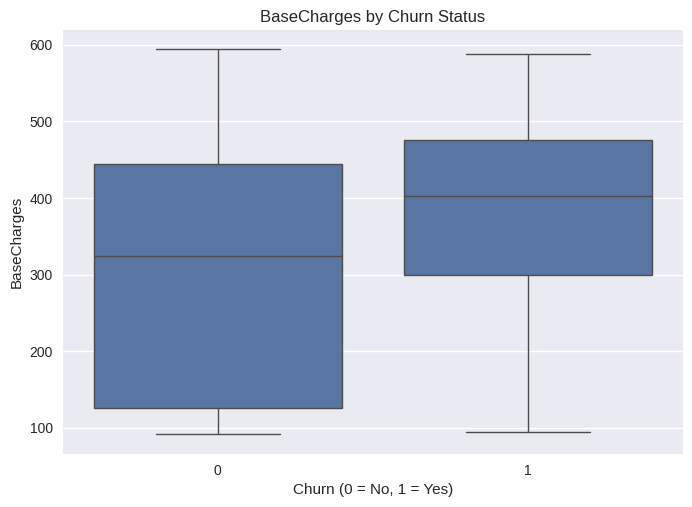

In [22]:
#base charges by churn (0,1)
sns.boxplot(x='Churn', y='BaseCharges', data=train_full)
plt.title('BaseCharges by Churn Status')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.show()

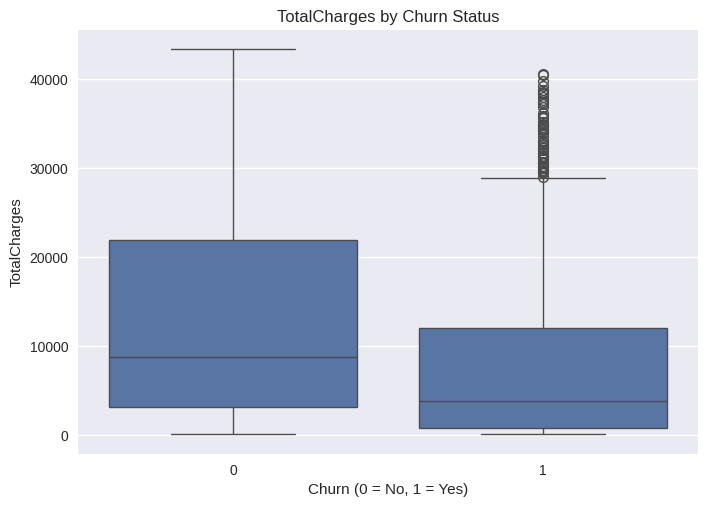

In [23]:
# total charges by churn

sns.boxplot(x='Churn', y='TotalCharges', data=train_full)
plt.title('TotalCharges by Churn Status')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.show()

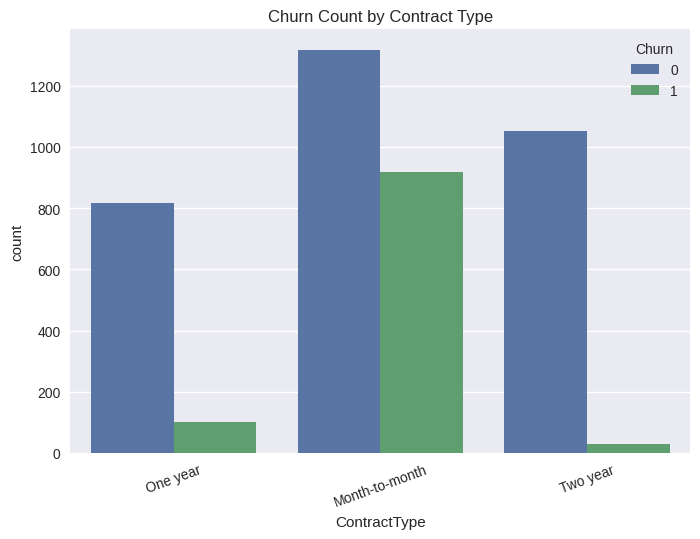

In [24]:
# Churn by ContractType
sns.countplot(x='ContractType', hue='Churn', data=train_full)
plt.title('Churn Count by Contract Type')
plt.xticks(rotation=20)
plt.show()

In [25]:
#fill median values in TotalCharges
median_total_charges = train_full['TotalCharges'].median()

train_full['TotalCharges'].fillna(median_total_charges, inplace=True)
test_full['TotalCharges'].fillna(median_total_charges, inplace=True)

train_full['TotalCharges'].isnull()

/tmp/ipykernel_3610/3952659575.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_full['TotalCharges'].fillna(median_total_charges, inplace=True)
/tmp/ipykernel_3610/3952659575.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value,

,TotalCharges
0,False
1,False
2,False
3,False
4,False
...,...
4233,False
4234,False
4235,False
4236,False


In [26]:
#find amount of time customer has been with the bank based on the date columns
train_full['DOC'] = pd.to_datetime(train_full['DOC'], dayfirst=True)
train_full['DOE'] = pd.to_datetime(train_full['DOE'], dayfirst=True)
train_full['Tenure'] = ((train_full['DOC'] - train_full['DOE']).dt.days / 30).abs().round(1)
train_full.drop(columns=['DOC', 'DOE'], inplace=True)

test_full['DOC'] = pd.to_datetime(test_full['DOC'], dayfirst=True)
test_full['DOE'] = pd.to_datetime(test_full['DOE'], dayfirst=True)
test_full['Tenure'] = ((test_full['DOC'] - test_full['DOE']).dt.days / 30).abs().round(1)
test_full.drop(columns=['DOC', 'DOE'], inplace=True)

train_full[['CustomerNo', 'Tenure']].head()

/tmp/ipykernel_3610/2036464943.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  train_full['DOE'] = pd.to_datetime(train_full['DOE'], dayfirst=True)
/tmp/ipykernel_3610/2036464943.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  test_full['DOE'] = pd.to_datetime(test_full['DOE'], dayfirst=True)


,CustomerNo,Tenure
0,1201,12.0
1,1202,1.0
2,1205,1.0
3,1206,71.0
4,1207,28.0


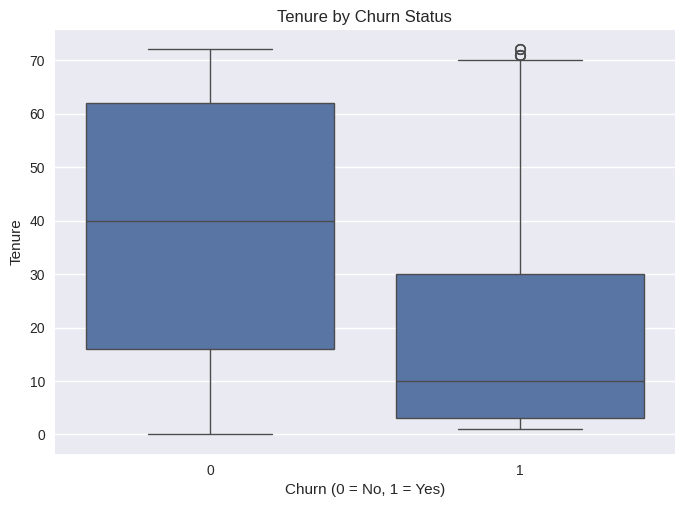

In [27]:
# tenure by churn

sns.boxplot(x='Churn', y='Tenure', data=train_full)
plt.title('Tenure by Churn Status')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.show()

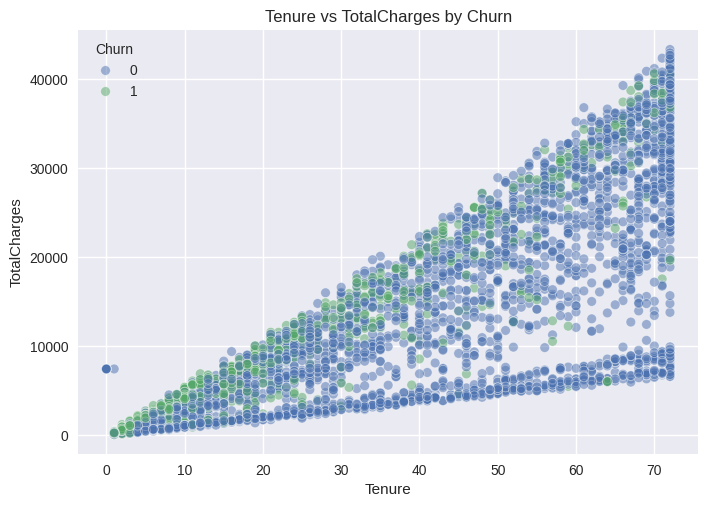

In [28]:
# Tenure vs TotalCharges
sns.scatterplot(x='Tenure', y='TotalCharges', hue='Churn', data=train_full, alpha=0.5)
plt.title('Tenure vs TotalCharges by Churn')
plt.show()

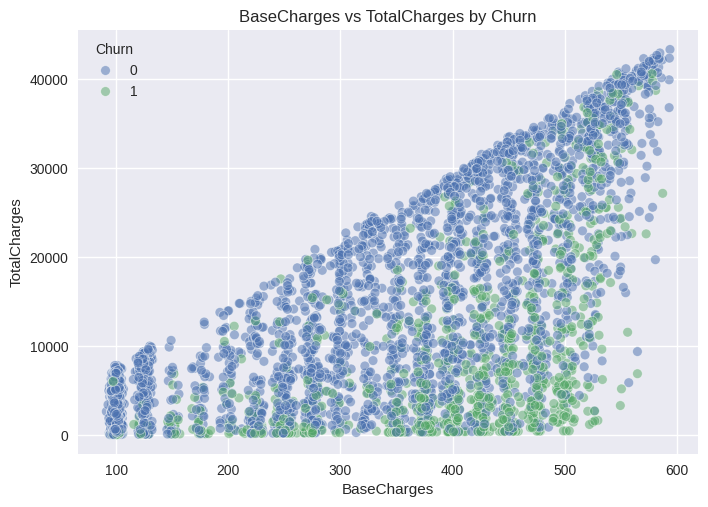

In [29]:
# BaseCharges vs TotalCharges
sns.scatterplot(x='BaseCharges', y='TotalCharges', hue='Churn', data=train_full, alpha=0.5)
plt.title('BaseCharges vs TotalCharges by Churn')
plt.show()

In [30]:
#processing the target
# set the target - seperating the Y (depdendent variable) from the rest
y_train = train_full['Churn']

train_full = train_full.drop(columns=['CustomerNo', 'Churn'])
test_full  = test_full.drop(columns=['CustomerNo'])

train_full.info()
test_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   DeviceProtection         4238 non-null   object 
 1   HasPhoneService          4238 non-null   object 
 2   InternetServiceCategory  4238 non-null   object 
 3   MultipleLines            4238 non-null   object 
 4   OnlineBackup             4238 non-null   object 
 5   OnlineSecurity           4238 non-null   object 
 6   StreamingMovies          4238 non-null   object 
 7   StreamingTelevision      4238 non-null   object 
 8   TechnicalSupport         4238 non-null   object 
 9   Country                  4238 non-null   object 
 10  State                    4238 non-null   object 
 11  Retired                  4238 non-null   int64  
 12  HasPartner               4238 non-null   int64  
 13  HasDependents            4238 non-null   int64  
 14  Education               

In [31]:
#fill missing categorical values with the mode
for col in ['Education', 'Gender', 'ContractType']:
    mode_val = train_full[col].mode()[0]
    train_full[col].fillna(mode_val, inplace=True)
    test_full[col].fillna(mode_val, inplace=True)

train_full[['Education', 'Gender', 'ContractType']].isnull()

/tmp/ipykernel_3610/3972882502.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_full[col].fillna(mode_val, inplace=True)
/tmp/ipykernel_3610/3972882502.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

,Education,Gender,ContractType
0,False,False,False
1,False,False,False
2,False,False,False
3,False,False,False
4,False,False,False
...,...,...,...
4233,False,False,False
4234,False,False,False
4235,False,False,False
4236,False,False,False


In [32]:
num_cols = train_full.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = train_full.select_dtypes(include=['object']).columns.tolist()


#the encoder below would  not run until i printed the column names as a list
print('Numeric columns:', num_cols)
print()
print('Categorical columns:', cat_cols)

Numeric columns: ['Retired', 'HasPartner', 'HasDependents', 'BaseCharges', 'TotalCharges', 'Tenure']

Categorical columns: ['DeviceProtection', 'HasPhoneService', 'InternetServiceCategory', 'MultipleLines', 'OnlineBackup', 'OnlineSecurity', 'StreamingMovies', 'StreamingTelevision', 'TechnicalSupport', 'Country', 'State', 'Education', 'Gender', 'ElectronicBilling', 'ContractType', 'PaymentMethod']


In [33]:
#16 objects need encoding
#encode the categorical categories
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder()

train_full[cat_cols] = ordinal_encoder.fit_transform(train_full[cat_cols])
test_full[cat_cols]  = ordinal_encoder.transform(test_full[cat_cols])



In [34]:
#scale the numeric columns
#puts everything in the 0-1 range so no columns dominate the model just because their numbers are larger
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

train_full[num_cols] = scaler.fit_transform(train_full[num_cols])
test_full[num_cols]  = scaler.transform(test_full[num_cols])

train_full[num_cols].describe()

,Retired,HasPartner,HasDependents,BaseCharges,TotalCharges,Tenure
count,4238.000000,4238.000000,4238.000000,4238.000000,4238.000000,4238.000000
mean,0.156678,0.503067,0.693016,0.466991,0.273281,0.467778
std,0.363540,0.500050,0.461297,0.300829,0.265901,0.342628
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.183582,0.050950,0.138889
50%,0.000000,1.000000,1.000000,0.519652,0.170181,0.430556
75%,0.000000,1.000000,1.000000,0.717910,0.458637,0.791667
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [35]:
#convert to dfs
train_full = pd.DataFrame(train_full, columns=num_cols + cat_cols)
test_full  = pd.DataFrame(test_full,  columns=num_cols + cat_cols)

train_full.head()

,Retired,HasPartner,HasDependents,BaseCharges,TotalCharges,Tenure,DeviceProtection,HasPhoneService,InternetServiceCategory,MultipleLines,...,StreamingMovies,StreamingTelevision,TechnicalSupport,Country,State,Education,Gender,ElectronicBilling,ContractType,PaymentMethod
0,0.0,1.0,1.0,0.770647,0.134643,0.166667,2.0,1.0,1.0,0.0,...,2.0,2.0,0.0,1.0,1.0,2.0,1.0,0.0,1.0,2.0
1,0.0,1.0,1.0,0.023881,0.000208,0.013889,1.0,1.0,2.0,0.0,...,1.0,1.0,1.0,1.0,1.0,4.0,1.0,0.0,0.0,2.0
2,0.0,1.0,1.0,0.559701,0.006431,0.013889,0.0,1.0,1.0,2.0,...,0.0,0.0,0.0,1.0,1.0,4.0,0.0,1.0,0.0,2.0
3,0.0,1.0,1.0,0.016418,0.154416,0.986111,1.0,1.0,2.0,0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0
4,0.0,1.0,1.0,0.000000,0.059611,0.388889,1.0,1.0,2.0,0.0,...,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0


In [36]:
#train a DT model

from sklearn.tree import DecisionTreeClassifier

tree_clf1 = DecisionTreeClassifier(criterion='entropy', max_depth=3)
tree_clf1.fit(train_full, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3)

In [37]:
test_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1060 entries, 0 to 1059
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Retired                  1060 non-null   float64
 1   HasPartner               1060 non-null   float64
 2   HasDependents            1060 non-null   float64
 3   BaseCharges              1060 non-null   float64
 4   TotalCharges             1060 non-null   float64
 5   Tenure                   1060 non-null   float64
 6   DeviceProtection         1060 non-null   float64
 7   HasPhoneService          1060 non-null   float64
 8   InternetServiceCategory  1060 non-null   float64
 9   MultipleLines            1060 non-null   float64
 10  OnlineBackup             1060 non-null   float64
 11  OnlineSecurity           1060 non-null   float64
 12  StreamingMovies          1060 non-null   float64
 13  StreamingTelevision      1060 non-null   float64
 14  TechnicalSupport        

In [38]:
# make prediction using the decision tree
y_hat = tree_clf1.predict(test_full)
y_hat.shape

(1060,)

In [39]:
# convert to integer (without this, Kaggle score will be 0)
y_hat = y_hat.astype(int)
y_hat

array([1, 0, 0, ..., 1, 0, 0])

In [40]:
# make the submission dataframe with the two required columns
tree1_submit = pd.DataFrame({
    'CustomerNo': test_customer_ids,
    'Churn': y_hat,
})

tree1_submit.head()

,CustomerNo,Churn
0,1203,1
1,1204,0
2,1208,0
3,1220,0
4,1221,0


In [41]:
# save as csv for Kaggle submission
tree1_submit.to_csv(f'{output_dir}/tree1_submit.csv', index=False)

Lin reg model

In [42]:
from sklearn.linear_model import LogisticRegression

lr_df = LogisticRegression(max_iter=1000, random_state=42)
lr_df.fit(train_full, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [43]:
#pred
y_hat_lr = lr_df.predict(test_full)
y_hat_lr.shape

(1060,)

In [44]:
# convert to integer
y_hat_lr = y_hat_lr.astype(int)
y_hat_lr

array([0, 0, 0, ..., 1, 0, 0])

In [45]:
# make the submission dataframe
lr_submit = pd.DataFrame({'CustomerNo': test_customer_ids,'Churn': y_hat_lr,})
lr_submit.head()

,CustomerNo,Churn
0,1203,0
1,1204,0
2,1208,0
3,1220,0
4,1221,0


In [46]:
# save as csv for Kaggle submission
lr_submit.to_csv(f'{output_dir}/lr_submit.csv', index=False)

random forest

In [47]:
from sklearn.ensemble import RandomForestClassifier

rf_classifier = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_classifier.fit(train_full, y_train)

RandomForestClassifier(max_depth=5, random_state=42)

In [48]:
# make prediction using random forest
y_hat_rf = rf_classifier.predict(test_full)
y_hat_rf.shape

(1060,)

In [49]:
# convert to integer
y_hat_rf = y_hat_rf.astype(int)
y_hat_rf

array([0, 0, 0, ..., 1, 0, 0])

In [50]:
# make the submission dataframe
rf_submit = pd.DataFrame({'CustomerNo': test_customer_ids,'Churn': y_hat_rf,})
rf_submit.head()

,CustomerNo,Churn
0,1203,0
1,1204,0
2,1208,0
3,1220,0
4,1221,0


In [51]:
# save as csv for Kaggle submission
rf_submit.to_csv(f'{output_dir}/rf_submit.csv', index=False)